# Predicting Loan Payback Model

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold # Best for classification/imbalance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [4]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [5]:
# STEP 2: Load the datasets
# -----------------------------
train = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/train.csv")
test = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/test.csv")
sample_submission = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/sample_submission.csv")

In [5]:
# STEP 3: Basic info
print(train.shape)
print(test.shape)
print(sample_submission.shape)

(593994, 13)
(254569, 12)
(254569, 2)


In [6]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [9]:
test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [11]:
sample_submission.head()

,id,loan_paid_back
0,593994,0
1,593995,0
2,593996,0
3,593997,0
4,593998,0


In [16]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [13]:
train.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [14]:
test.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000
mean,721278.000000,48233.080193,0.120583,681.037691,15016.753484,12.352323
std,73487.884676,26719.658580,0.068582,55.624118,6922.165182,2.017602
min,593994.000000,6011.770000,0.011000,395.000000,500.050000,3.200000
25%,657636.000000,27950.300000,0.072000,646.000000,10248.580000,10.980000
50%,721278.000000,46528.980000,0.096000,683.000000,15000.220000,12.370000
75%,784920.000000,61149.440000,0.156000,719.000000,18831.460000,13.690000
max,848562.000000,380653.940000,0.627000,849.000000,48959.260000,21.290000


In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    254569 non-null  int64  
 1   annual_income         254569 non-null  float64
 2   debt_to_income_ratio  254569 non-null  float64
 3   credit_score          254569 non-null  int64  
 4   loan_amount           254569 non-null  float64
 5   interest_rate         254569 non-null  float64
 6   gender                254569 non-null  object 
 7   marital_status        254569 non-null  object 
 8   education_level       254569 non-null  object 
 9   employment_status     254569 non-null  object 
 10  loan_purpose          254569 non-null  object 
 11  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 23.3+ MB


In [14]:
train.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

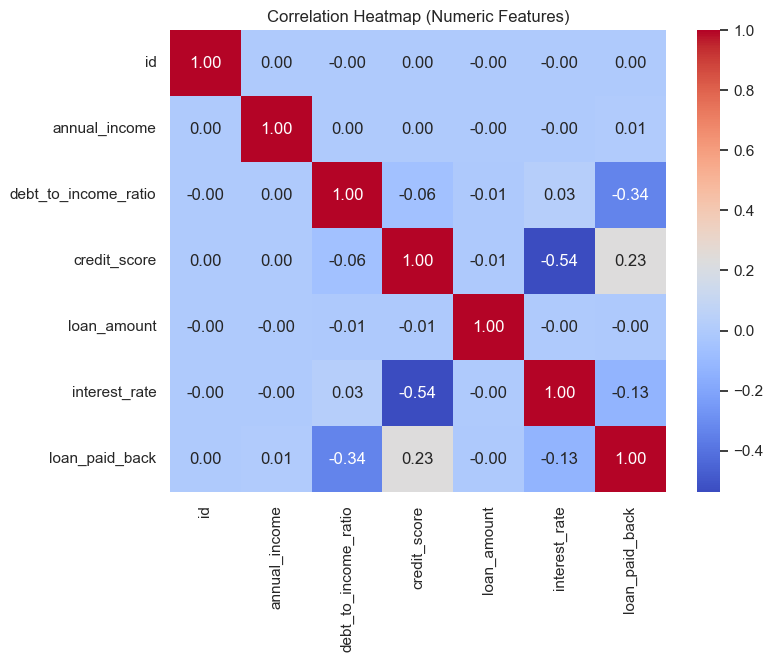

In [15]:
#🧠 1. Correlation Heatmap (Numeric Features)
#🔍 Interpretation

# This heatmap will show how numeric features relate to each other and to the target loan_paid_back.

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

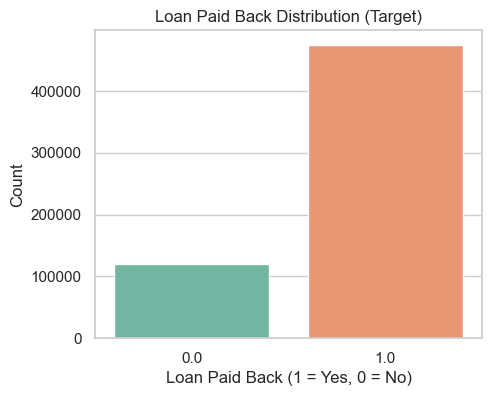

In [16]:
#📈 2. Target Distribution Plot
#🔍 Interpretation

#This chart displays the balance between loans repaid (1) and not repaid (0).

plt.figure(figsize=(5,4))
sns.countplot(x='loan_paid_back', data=train, palette="Set2")
plt.title("Loan Paid Back Distribution (Target)")
plt.xlabel("Loan Paid Back (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Feature Scaling

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

# --- Separate features and target ---
X = train.drop(columns=['loan_paid_back', 'id'])
y = train['loan_paid_back']

# --- Identify column types ---
num_features = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
cat_features = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# --- Build preprocessing pipeline ---
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# --- Example model pipeline (Logistic Regression) ---
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# --- Train/test split ---
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Fit model ---
clf.fit(X_train, y_train)

# --- Validation accuracy ---
print("Validation Accuracy:", clf.score(X_valid, y_valid))


Validation Accuracy: 0.8614213924359633


In [19]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predictions
y_pred = clf.predict(X_valid)
y_proba = clf.predict_proba(X_valid)[:, 1]

# Evaluation
print("ROC-AUC Score:", roc_auc_score(y_valid, y_proba))
print("\nClassification Report:\n", classification_report(y_valid, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred))


ROC-AUC Score: 0.9106886303831235

Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.77      0.69     23900
         1.0       0.94      0.88      0.91     94899

    accuracy                           0.86    118799
   macro avg       0.78      0.83      0.80    118799
weighted avg       0.88      0.86      0.87    118799


Confusion Matrix:
 [[18381  5519]
 [10944 83955]]


In [20]:
!pip install xgboost
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False)
}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_valid)
    y_proba = pipe.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_proba)
    print(f"{name}: ROC-AUC = {auc:.4f}")


Logistic Regression: ROC-AUC = 0.9107
Random Forest: ROC-AUC = 0.9065
Gradient Boosting: ROC-AUC = 0.9149


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [07:56:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: ROC-AUC = 0.9196


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# XGBoost model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    tree_method='hist'
)

# Build full pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb)
])

# Parameter grid (note the 'model__' prefix)
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

# Grid Search
grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("✅ Best parameters:", grid.best_params_)
print("🏆 Best ROC-AUC:", grid.best_score_)



Fitting 3 folds for each of 72 candidates, totalling 216 fits
✅ Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__subsample': 1.0}
🏆 Best ROC-AUC: 0.9210004202109144


In [22]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Load test set
train = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/train.csv")

# Use the best parameters you found
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.2,
    'max_depth': 4,
    'n_estimators': 400,
    'subsample': 1.0
}

# Build final model
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
        **best_params
    ))
])

# Fit on FULL training data
final_model.fit(X, y)

# Predict probabilities for test data
test_probs = final_model.predict_proba(test)[:, 1]

# Create submission dataframe
submission = pd.DataFrame({
    "id": test["id"],
    "loan_paid_back": test_probs
})

# Save file
submission.to_csv("submission.csv", index=False)

print("Done! File 'submission.csv' is created.")


Done! File 'submission.csv' is created.


In [23]:
!pip install catboost


In [24]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
cat_indices = [X_train.columns.get_loc(col) for col in cat_features]


In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_model = CatBoostClassifier(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    cat_features=cat_indices    # <--- IMPORTANT: put here
)

cat_model.fit(
    X_train, 
    y_train,
    eval_set=(X_valid, y_valid)
)

preds = cat_model.predict_proba(X_valid)[:, 1]
print("CatBoost AUC:", roc_auc_score(y_valid, preds))


CatBoost AUC: 0.921058357087943


# Level 2 Super Learner off + Meta

In [12]:
import numpy as np
import pandas as pd

class SimpleTargetEncoder:
    def __init__(self, cols, smoothing=1.0):
        self.cols = cols
        self.smoothing = smoothing
        self.target_means = {}
        self.global_mean = None

    def fit(self, X, y):
        X = X.copy()
        self.global_mean = y.mean()

        for col in self.cols:
            stats = (
                X.groupby(col)[y.name]
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'cat_mean', 'count': 'n'})
            )
            smoothing = 1 / (1 + np.exp(-(stats['n'] - self.smoothing)))
            stats['encoded'] = self.global_mean * (1 - smoothing) + stats['cat_mean'] * smoothing
            self.target_means[col] = stats['encoded']
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.target_means[col]).fillna(self.global_mean)
        return X

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)


In [33]:
# LEVEL-2 SUPER LEARNER (OOF + META) 
!pip install --upgrade scikit-learn
!pip install lightgbm


import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

# --------------------------
# CONFIG
# --------------------------
N_FOLDS = 5
RANDOM_SEEDS = [42, 2024]   # seed averaging for robustness (add seeds if you want)
TARGET = "loan_paid_back"
ID_COL = "id"

# --------------------------
# LOAD DATA
# --------------------------
train = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/train.csv")
test = pd.read_csv("C:/Users/User/Downloads/playground-series-s5e11/test.csv")
# Separate
X_full = train.drop(columns=[TARGET, ID_COL])
y_full = train[TARGET].astype(int)
X_test_full = test.drop(columns=[ID_COL])

# Identify columns
numerical_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_full.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical cols:", numerical_cols)
print("Categorical cols:", categorical_cols)

# --------------------------
# Helper: generate OOF preds for one model (with per-fold target encoding + scaling)
# --------------------------
def get_oof_and_test_preds(model_builder, X, y, X_test, 
                           numerical_cols, categorical_cols, n_splits=5, seed=42):
    """
    model_builder(seed) -> returns a fresh (unfitted) estimator instance
    Returns:
      oof_preds (n_samples,), test_preds (n_test,)
    """
    oof_preds = np.zeros(len(X))
    test_preds_folds = np.zeros((n_splits, len(X_test)))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        # Target encode categorical columns (fit on train fold only)
        te = TargetEncoder(cols=categorical_cols, smoothing=0.2)
        X_tr_te = te.fit_transform(X_tr, y_tr)
        X_val_te = te.transform(X_val)
        X_test_te = te.transform(X_test)
        
        # Scale numeric columns (fit on train fold only)
        scaler = StandardScaler()
        X_tr_te[numerical_cols] = scaler.fit_transform(X_tr_te[numerical_cols])
        X_val_te[numerical_cols] = scaler.transform(X_val_te[numerical_cols])
        X_test_te[numerical_cols] = scaler.transform(X_test_te[numerical_cols])
        
        # Build model and fit
        model = model_builder(seed + fold)  # create model instance
        model.fit(X_tr_te, y_tr)
        
        # Predict
        oof_preds[val_idx] = model.predict_proba(X_val_te)[:, 1]
        test_preds_folds[fold, :] = model.predict_proba(X_test_te)[:, 1]
        
        # Free memory
        del te, scaler, X_tr_te, X_val_te, X_test_te, model
    
    # Average test predictions across folds
    test_preds = test_preds_folds.mean(axis=0)
    return oof_preds, test_preds

# --------------------------
# MODEL BUILDERS
# --------------------------
def build_xgb(seed=42):
    return XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=seed,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

def build_lgb(seed=42):
    return LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        colsample_bytree=0.8,
        subsample=0.8,
        random_state=seed,
        n_jobs=-1
    )

def build_cat(seed=42):
    return CatBoostClassifier(
        iterations=1500,
        depth=6,
        learning_rate=0.03,
        l2_leaf_reg=5,
        random_seed=seed,
        verbose=False
    )

def build_gb(seed=42):
    return GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=seed
    )

def build_lr(seed=42):
    return LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed)

# --------------------------
# LEVEL-1 MODELS (order matters for stacking list)
# --------------------------
l1_models = [
    ("xgb", build_xgb),
    ("lgb", build_lgb),
    ("cat", build_cat),
    ("gb", build_gb),
    ("lr", build_lr)
]

# --------------------------
# TRAIN L1 (OOF) and COLLECT META FEATURES (can average across seeds)
# --------------------------
# I'll create arrays to store averaged OOF and test preds across seeds
meta_train = np.zeros((len(X_full), len(l1_models)))
meta_test = np.zeros((len(X_test_full), len(l1_models)))

for i, (name, builder) in enumerate(l1_models):
    print(f"\n>>> Generating OOF for {name.upper()}")
    oof_accum = np.zeros(len(X_full))
    test_accum = np.zeros(len(X_test_full))
    
    for seed in RANDOM_SEEDS:
        oof, test_preds = get_oof_and_test_preds(builder, X_full, y_full, X_test_full, 
                                                numerical_cols, categorical_cols,
                                                n_splits=N_FOLDS, seed=seed)
        oof_accum += oof
        test_accum += test_preds
    
    # average across seeds
    oof_mean = oof_accum / len(RANDOM_SEEDS)
    test_mean = test_accum / len(RANDOM_SEEDS)
    
    meta_train[:, i] = oof_mean
    meta_test[:, i] = test_mean
    
    fold_auc = roc_auc_score(y_full, oof_mean)
    print(f"{name.upper()} OOF ROC-AUC (averaged seeds): {fold_auc:.6f}")

# --------------------------
# Prepare meta training set
# --------------------------
meta_cols = [f"{name}_oof" for name, _ in l1_models]
meta_train_df = pd.DataFrame(meta_train, columns=meta_cols)
meta_test_df = pd.DataFrame(meta_test, columns=meta_cols)


# include credit_score and debt_to_income_ratio scaled
meta_extra = X_full[['credit_score', 'debt_to_income_ratio']].copy()
meta_extra_test = X_test_full[['credit_score', 'debt_to_income_ratio']].copy()

sc = StandardScaler()
meta_extra = pd.DataFrame(sc.fit_transform(meta_extra), columns=meta_extra.columns)
meta_extra_test = pd.DataFrame(sc.transform(meta_extra_test), columns=meta_extra_test.columns)

meta_train_df = pd.concat([meta_train_df, meta_extra.reset_index(drop=True)], axis=1)
meta_test_df = pd.concat([meta_test_df, meta_extra_test.reset_index(drop=True)], axis=1)

print("\nMeta train shape:", meta_train_df.shape)
print("Meta test shape:", meta_test_df.shape)

# --------------------------
# LEVEL-2: TRAIN META MODEL (XGBoost)
# --------------------------
print("\n>>> Training Level-2 meta model (XGBoost)")

meta_model = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

# Cross-validate meta model with stratified folds for a reliable AUC
meta_oof = np.zeros(len(meta_train_df))
meta_test_preds_folds = np.zeros((N_FOLDS, len(meta_test_df)))
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(skf.split(meta_train_df, y_full)):
    X_tr_meta, X_val_meta = meta_train_df.iloc[tr_idx], meta_train_df.iloc[val_idx]
    y_tr_meta, y_val_meta = y_full.iloc[tr_idx], y_full.iloc[val_idx]
    
    meta_model.fit(X_tr_meta, y_tr_meta)
    meta_oof[val_idx] = meta_model.predict_proba(X_val_meta)[:, 1]
    meta_test_preds_folds[fold, :] = meta_model.predict_proba(meta_test_df)[:, 1]

meta_auc = roc_auc_score(y_full, meta_oof)
meta_test_preds = meta_test_preds_folds.mean(axis=0)

print("Meta OOF ROC-AUC:", meta_auc)

# --------------------------
# SUBMISSION
# --------------------------
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: meta_test_preds
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv (stacked predictions).")

# Optionally save models/meta features
joblib.dump(meta_model, "meta_model.joblib")
print("Saved meta model to meta_model.joblib")


Numerical cols: ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Categorical cols: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

>>> Generating OOF for XGB
XGB OOF ROC-AUC (averaged seeds): 0.921130

>>> Generating OOF for LGB
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1335
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise mul

In [34]:
meta_train_df.to_csv("meta_train_oof.csv", index=False)
meta_test_df.to_csv("meta_test_preds.csv", index=False)
